# Explore a trained encoder

Load an encoder checkpoint, visualize the similarity grid, plot the
unique radius polar, and run a few navigation trajectories.

Most of the logic lives in `encoder_training/{viz,trajectory,evaluate}.py`
— this notebook just glues things together.


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NB_DIR, '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from encoder_training.train import load_encoder
from encoder_training.data import build_full_grid
from encoder_training.evaluate import encode_grid
from encoder_training import viz, trajectory

## 1 · Load encoder and encode the full grid

In [2]:
# CKPT = '/home/jackking/cls/encoders/binary_20260420_183304/encoder_best.pt'
# CKPT = "/home/jackking/cls/encoders/binary_20260409_083227/encoder_final.pt"
# CKPT = "/home/jackking/cls/encoders/run_20260421_204648/encoder_best.pt" # - had ok place coding

CKPT = "/home/jackking/cls/encoders/run_20260422_185816/encoder_best.pt" # SOTA

UNTRAINED_CKPT = "/home/jackking/cls/encoders/untrained_mlp.pt"

SHUFFLED_CKPT = "/home/jackking/cls/encoders/run_20260424_005357/encoder_best.pt"

encoder, ckpt = load_encoder(CKPT)
device = next(encoder.parameters()).device
gain   = float(ckpt['gain'])
lambdas = ckpt['model_config']['lambdas']
y0s = ckpt['y0s']; x0s = ckpt['x0s']; sizes = ckpt['sizes']
fwhm = (ckpt.get('train_config') or {}).get('fwhm_ratio', 0.25)

print(f'Lambdas={lambdas}  gain={gain}  n_envs={len(sizes)}  '
      f'sizes={sorted(set(sizes))}')
if 'val_nav_acc' in ckpt:
    print(f'Saved peak val_nav_acc: {ckpt["val_nav_acc"]:.3f}')

Phi_full, full_Npos = build_full_grid(lambdas, fwhm_ratio=fwhm)
print(f'Encoding {full_Npos}x{full_Npos} grid...')
Z = encode_grid(encoder, Phi_full, gain, device)   # (H, W, D)
print('Encoded shape:', Z.shape)

Lambdas=[11, 12, 13]  gain=3.6986986986986987  n_envs=60  sizes=[100]
Saved peak val_nav_acc: 0.991
Encoding 1716x1716 grid...
Encoded shape: (1716, 1716, 1024)


## Place-field-style feature maps

Each panel shows one coordinate of the encoded vector **across space** (like the spatial receptive field of one hidden unit). Set **`VIEW_SIDE`** to zoom; use **`HIGHPASS_SIGMA`** (wide Gaussian subtracted) to emphasize local peaks vs slow background; set **`IMSHOW_VMAX_PCTL`** (e.g. `99`) so the colormap ignores hot outliers. Blur / rectification still help when channels are signed or noisy.

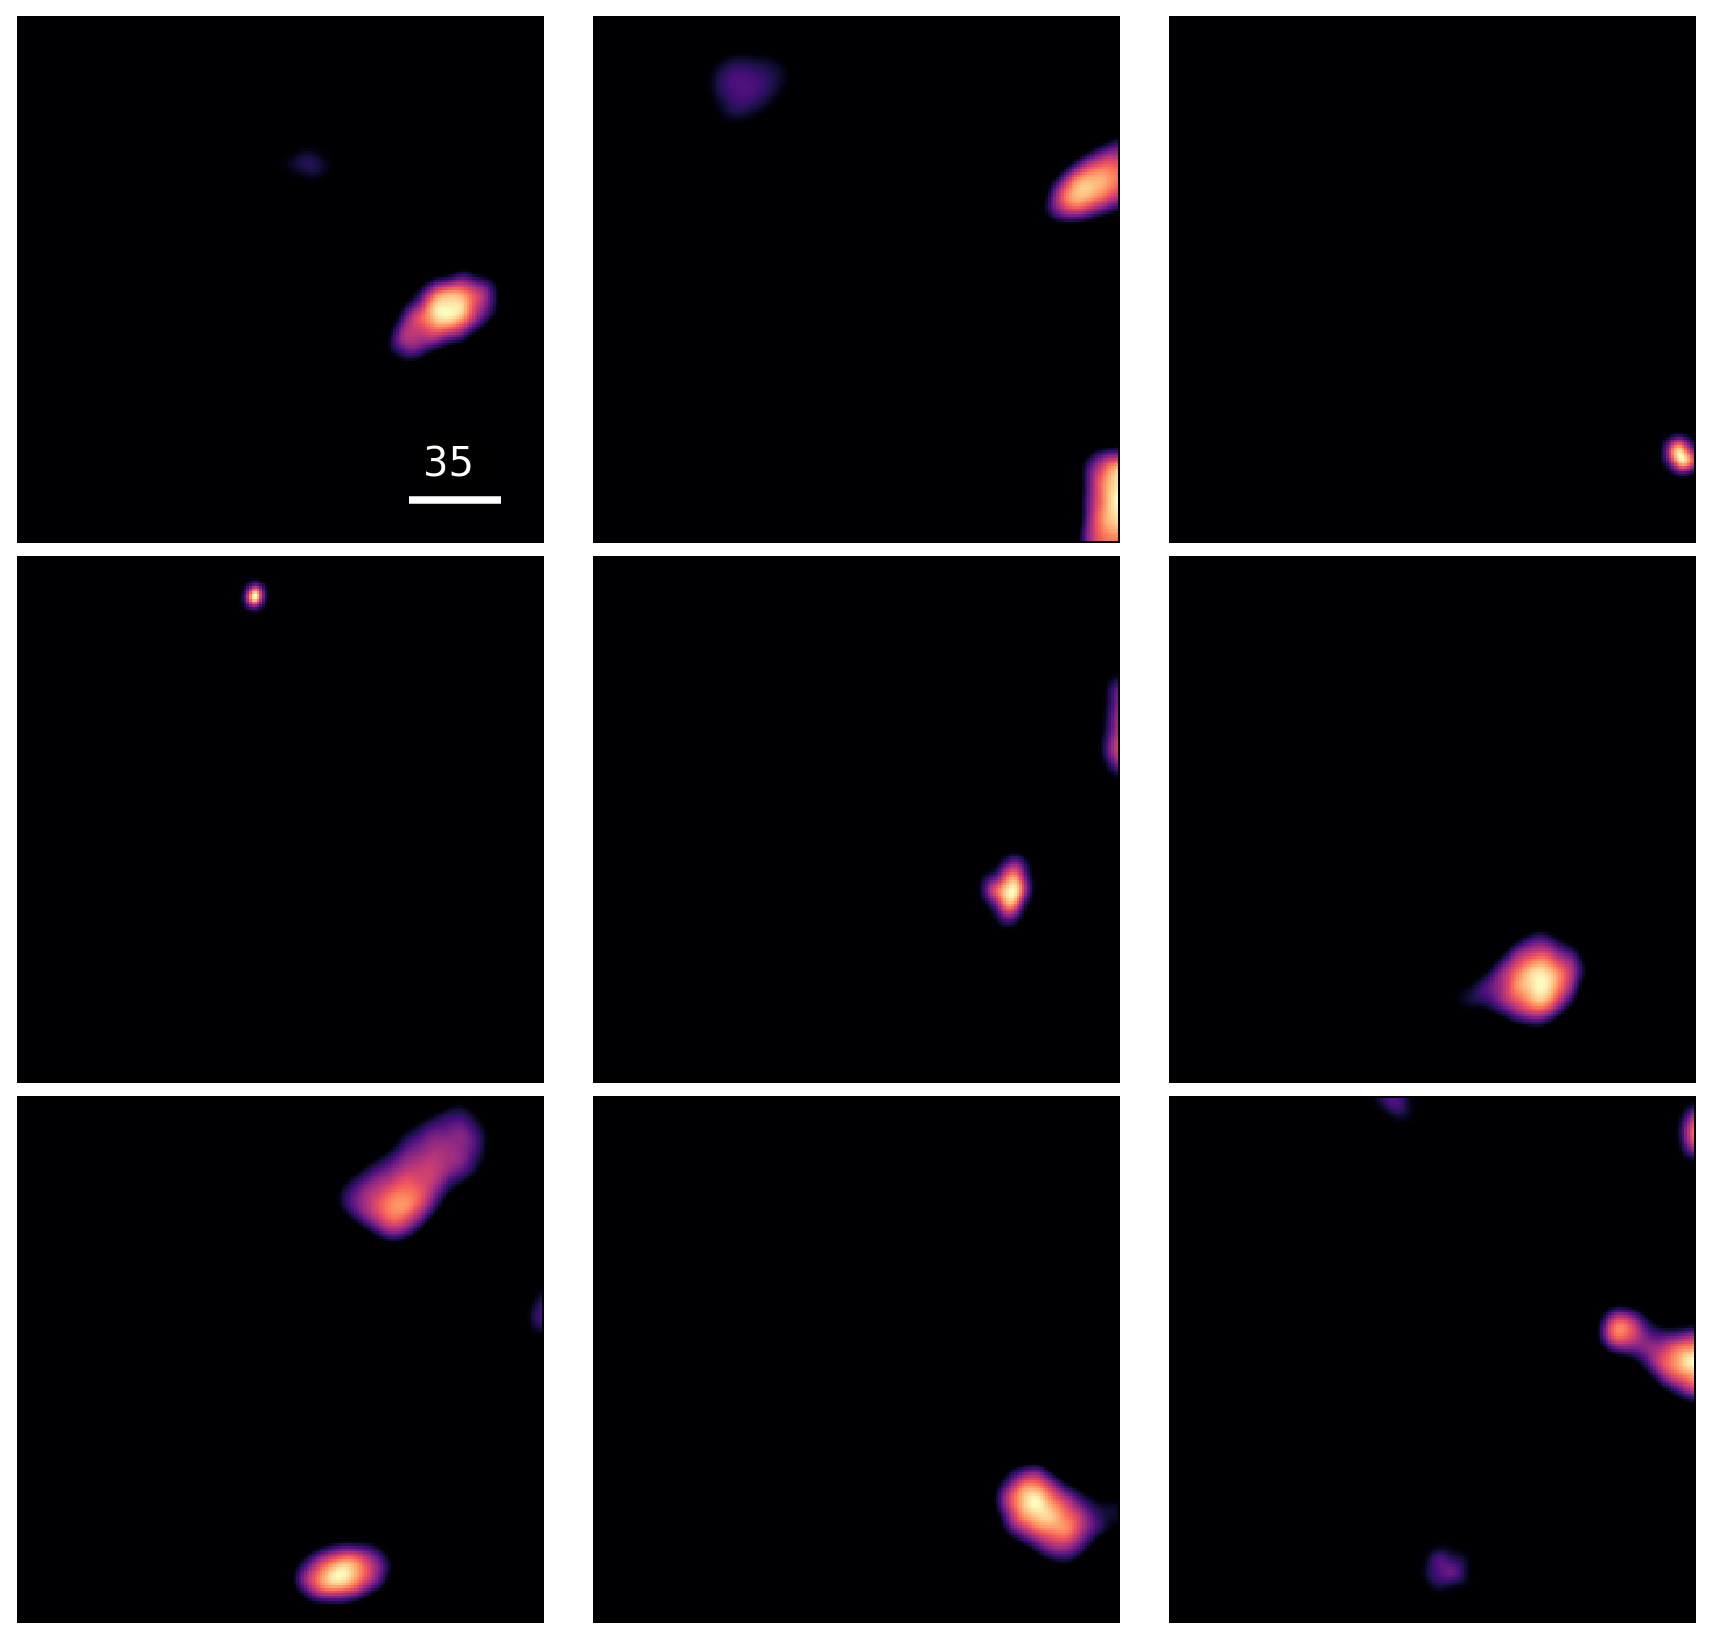

In [ ]:
from scipy.ndimage import gaussian_filter

# --- knobs: tweak to bring out localized bumps ---
PLACECELL_SEED = 11
N_FEATURES = 9           # how many random embedding dims to plot
VIEW_SIDE = 200           # None = full grid; else square window side length (cells)
VIEW_CENTER_YX = None     # None = grid center; else (row, col) center of that window
BLUR_SIGMA = 2.0          # Gaussian blur in grid cells; set 0 to disable
POSTPROCESS = "relu"      # "none" | "relu" | "abs" | "square" | "softplus"
RELU_THRESH = 0.05       # threshold for ReLU
SUBTRACT_GLOBAL_MEAN = True
NORMALIZE_EACH = False    # per-map min-max to [0, 1] after processing
HIGHPASS_SIGMA = 30.0     # subtract Gaussian(x,sigma); 0 = off
IMSHOW_VMIN_PCTL = None   # used only if IMSHOW_VMAX_PCTL is set; None -> vmin=0
IMSHOW_VMAX_PCTL = None   # e.g. 99.0 = colormap vmax at 99th percentile; None -> auto vmax

# --- paper-style display knobs ---
CELL_SIZE = 1.0           # physical size represented by one grid cell
CELL_UNITS = ""      # e.g. "m", "cm", "arb."
SHOW_SCALE_BAR = True
SCALE_BAR_FRAC = 0.175     # fraction of panel width

Z_full = np.asarray(Z)
H_full, W_full, D = Z_full.shape
if VIEW_SIDE is None:
    y0, x0, Z_np = 0, 0, Z_full
    H, W = H_full, W_full
    roi_note = "full grid"
else:
    s = int(min(int(VIEW_SIDE), H_full, W_full))
    cy = VIEW_CENTER_YX[0] if VIEW_CENTER_YX is not None else H_full // 2
    cx = VIEW_CENTER_YX[1] if VIEW_CENTER_YX is not None else W_full // 2
    y0 = int(np.clip(cy - s // 2, 0, H_full - s))
    x0 = int(np.clip(cx - s // 2, 0, W_full - s))
    Z_np = Z_full[y0 : y0 + s, x0 : x0 + s, :]
    H, W = Z_np.shape[0], Z_np.shape[1]
    roi_note = f"y in [{y0},{y0 + s}), x in [{x0},{x0 + s})"

rng = np.random.RandomState(PLACECELL_SEED)
n_show = min(N_FEATURES, D)
inds = rng.choice(D, size=n_show, replace=False)


def placefield_map(channel_2d: np.ndarray) -> np.ndarray:
    x = channel_2d.astype(np.float64, copy=False)
    if SUBTRACT_GLOBAL_MEAN:
        x = x - float(x.mean())
    if POSTPROCESS == "relu":
        x = np.maximum(RELU_THRESH, x)
    elif POSTPROCESS == "abs":
        x = np.abs(x)
    elif POSTPROCESS == "square":
        x = x * x
    elif POSTPROCESS == "softplus":
        z = np.clip(x, -20.0, 20.0)
        x = np.log1p(np.exp(z))
    elif POSTPROCESS != "none":
        raise ValueError(f"unknown POSTPROCESS={POSTPROCESS!r}")
    if HIGHPASS_SIGMA and HIGHPASS_SIGMA > 0:
        x = x - gaussian_filter(x, sigma=float(HIGHPASS_SIGMA))
    if BLUR_SIGMA and BLUR_SIGMA > 0:
        x = gaussian_filter(x, sigma=float(BLUR_SIGMA))
    if NORMALIZE_EACH:
        mn, mx = float(x.min()), float(x.max())
        if mx > mn:
            x = (x - mn) / (mx - mn)
        else:
            x = np.zeros_like(x)
    return x


def add_scale_bar(ax, extent, length, units):
    x_min, x_max, y_min, y_max = extent
    x_span = x_max - x_min
    y_span = y_max - y_min
    x1 = x_max - 0.08 * x_span
    x0_bar = x1 - length
    y0_bar = y_min + 0.08 * y_span
    ax.plot([x0_bar, x1], [y0_bar, y0_bar], color="white", lw=3, solid_capstyle="butt")
    ax.text(
        (x0_bar + x1) / 2,
        y0_bar + 0.03 * y_span,
        f"{int(length):g} {units}",
        color="white",
        ha="center",
        va="bottom",
        fontsize=16,
        bbox=dict(facecolor="black", alpha=0.35, edgecolor="none", pad=1.8),
    )


plt.rcParams.update(
    {
        "font.size": 13,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "figure.titlesize": 14,
        "savefig.dpi": 300,
    }
)

n_cols = 3
n_rows = int(np.ceil(n_show / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.2 * n_cols, 3.0 * n_rows),
    constrained_layout=True,
)
axes = np.atleast_2d(axes)

extent = [
    x0 * CELL_SIZE,
    (x0 + W) * CELL_SIZE,
    y0 * CELL_SIZE,
    (y0 + H) * CELL_SIZE,
]
scale_bar_len = max(CELL_SIZE, round((W * CELL_SIZE) * SCALE_BAR_FRAC, 2))

last_im = None
for i, d in enumerate(inds):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]
    m = placefield_map(Z_np[:, :, d])

    if IMSHOW_VMAX_PCTL is not None:
        vmax = float(np.percentile(m, IMSHOW_VMAX_PCTL))
        if IMSHOW_VMIN_PCTL is not None:
            vmin = float(np.percentile(m, IMSHOW_VMIN_PCTL))
        else:
            vmin = 0.0
        if vmax <= vmin:
            vmax = vmin + 1e-12
    else:
        vmin, vmax = 0.0, (1.0 if NORMALIZE_EACH else None)

    im = ax.imshow(
        m,
        cmap="magma",
        origin="lower",
        extent=extent,
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )
    last_im = im

    # ax.set_title(f"Cell {d}")
    # if c == 0:
    #     ax.set_ylabel(f"y ({CELL_UNITS})")
    # else:
    #     ax.set_yticklabels([])
    # if r == n_rows - 1:
    #     ax.set_xlabel(f"x ({CELL_UNITS})")
    # else:
    #     ax.set_xticklabels([])
    # ax.tick_params(length=2.5, width=0.8)

    #turn off ticks
    ax.set_xticks([])
    ax.set_yticks([])

    if SHOW_SCALE_BAR and i == 0:
        add_scale_bar(ax, extent, scale_bar_len, CELL_UNITS)

for j in range(n_show, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis("off")

roi_size_x = W * CELL_SIZE
roi_size_y = H * CELL_SIZE
subtitle = (
    f"ROI: {roi_size_x:g} x {roi_size_y:g} {CELL_UNITS} ({W} x {H}) | "
    f"blur sigma={BLUR_SIGMA} | post={POSTPROCESS}"
    + (f" | highpass sigma={HIGHPASS_SIGMA}" if HIGHPASS_SIGMA and HIGHPASS_SIGMA > 0 else "")
    + (" | mean-subtracted" if SUBTRACT_GLOBAL_MEAN else "")
    + (" | normalized" if NORMALIZE_EACH else "")
)

# plt.savefig(f'/home/jackking/cls/hopfield_nav/final_figures/placefield_map_{VIEW_SIDE}.pdf')
plt.show()

## 2 · Training environments

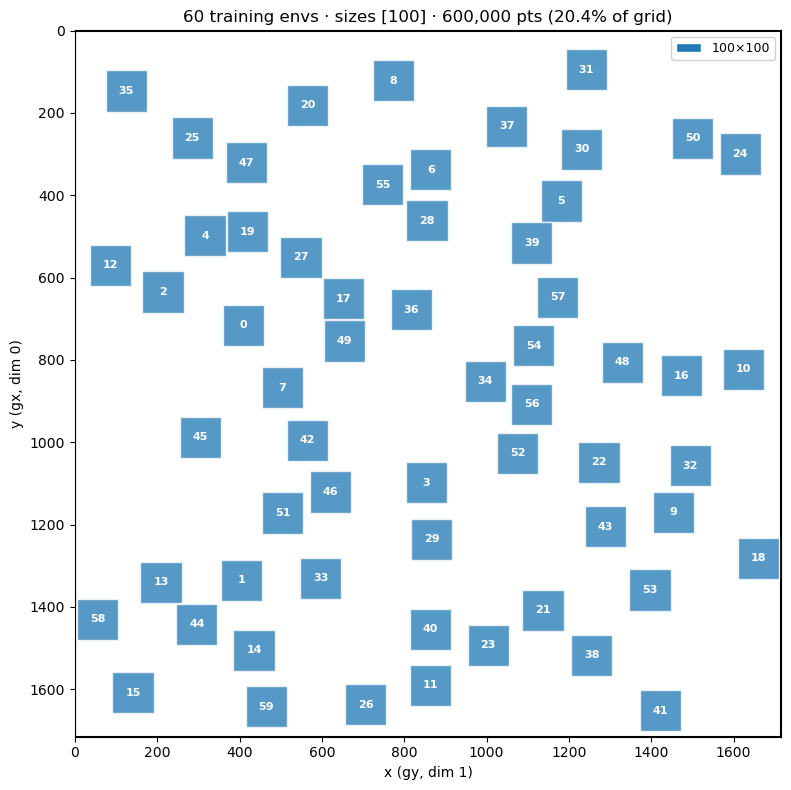

In [20]:
# Show the patches the encoder was trained on, overlaid on the full grid.
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-0.5, full_Npos - 0.5)
ax.set_ylim(full_Npos - 0.5, -0.5)    # image convention: origin top-left
ax.set_aspect('equal')
ax.add_patch(plt.Rectangle((0, 0), full_Npos, full_Npos,
                           fill=False, edgecolor='black', linewidth=1.5))

# Colour patches by size so mixed-Npos runs are easy to read.
unique_sizes = sorted(set(sizes))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(unique_sizes), 3)))
size_to_color = {s: cmap[i % len(cmap)] for i, s in enumerate(unique_sizes)}

for i, (y0, x0, s) in enumerate(zip(y0s, x0s, sizes)):
    ax.add_patch(plt.Rectangle((x0, y0), s, s,
                                facecolor=size_to_color[s], edgecolor='white',
                                linewidth=1.0, alpha=0.75))
    ax.text(x0 + s / 2, y0 + s / 2, str(i),
            ha='center', va='center', fontsize=12,
            fontweight='bold', color='white')

total_pts = int(sum(s * s for s in sizes))
coverage = 100 * total_pts / (full_Npos * full_Npos)
# No plot title for paper layout.
ax.set_xlabel('x (gy, dim 1)', fontsize=13)
ax.set_ylabel('y (gx, dim 0)', fontsize=13)
ax.tick_params(labelsize=12)

# Legend by patch size
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=size_to_color[s],
                         edgecolor='white', label=f'{s}×{s}')
           for s in unique_sizes]
ax.legend(handles=handles, loc='upper right', framealpha=0.9, fontsize=12)
plt.tight_layout()
plt.show()

## 3 · Similarity heatmap

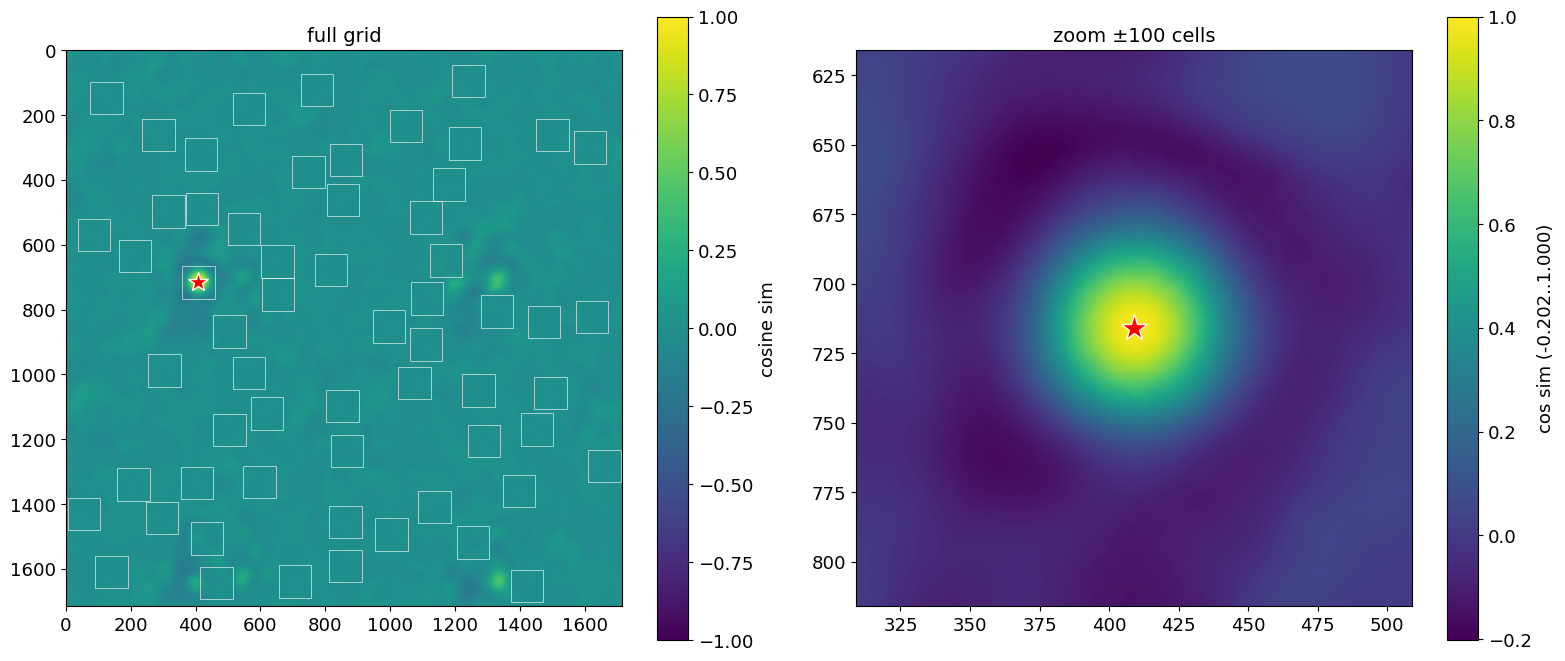

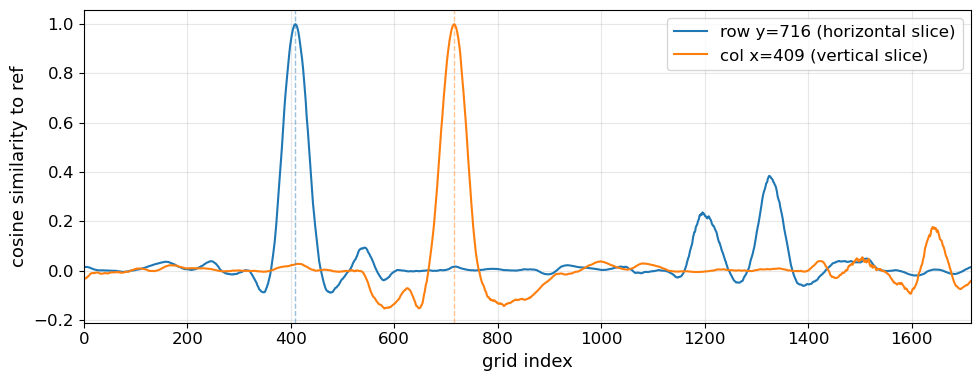

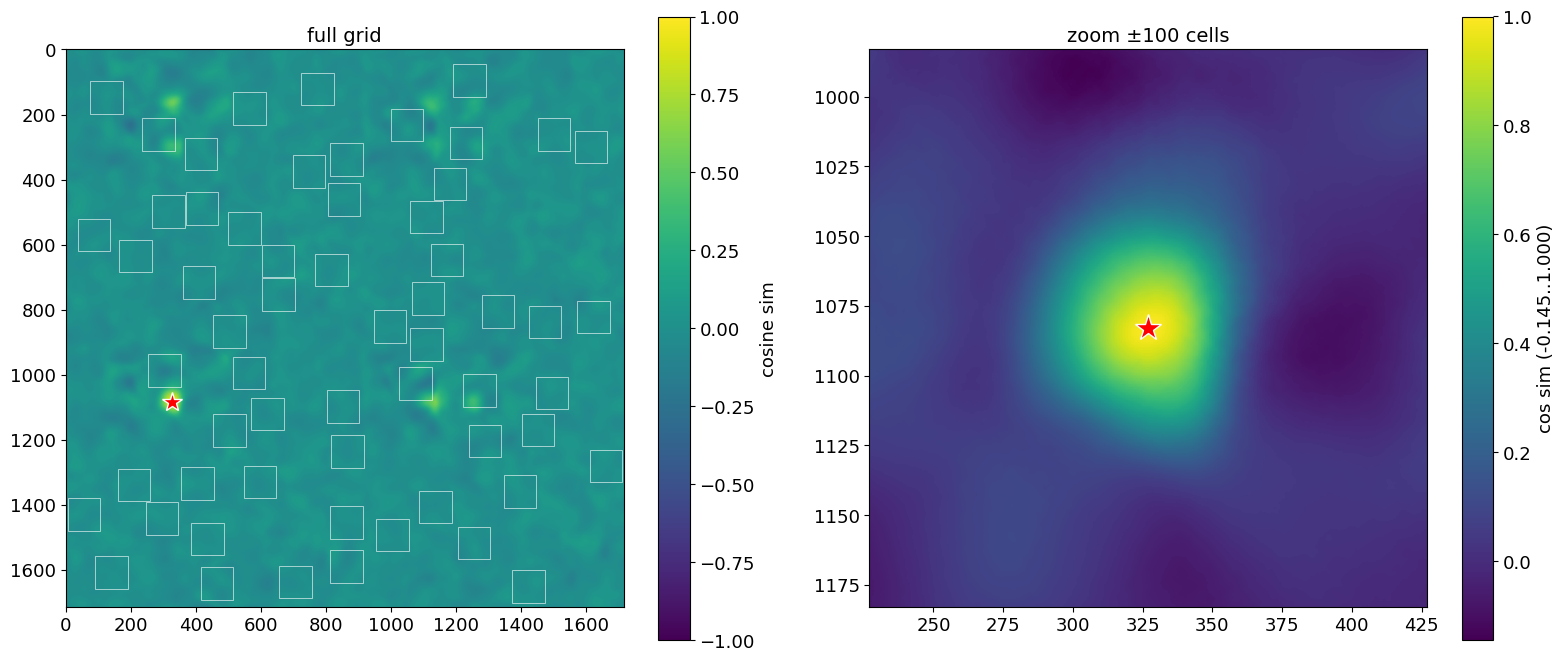

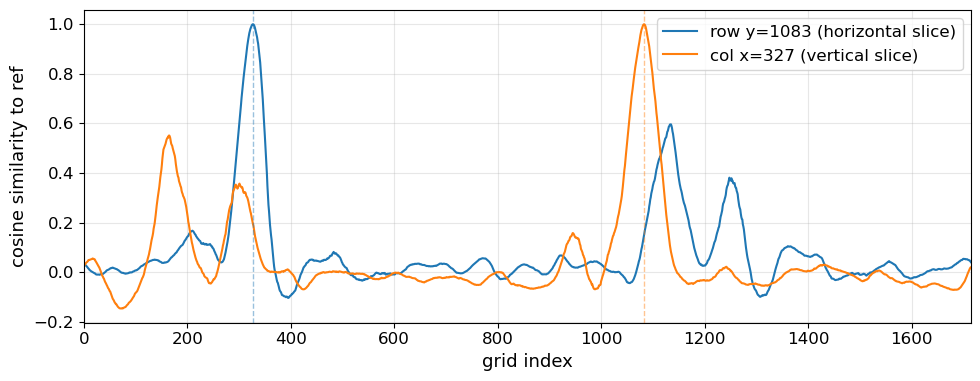

In [32]:
# Pick a reference point inside a training patch (and one outside) to contrast.
ref_train = (y0s[0] + sizes[0] // 2, x0s[0] + sizes[0] // 2)

def _first_outside(n=1000):
    rng = np.random.RandomState(0)
    for _ in range(n):
        y = int(rng.randint(50, full_Npos - 50))
        x = int(rng.randint(50, full_Npos - 50))
        if not any(y0 <= y < y0 + s and x0 <= x < x0 + s
                   for y0, x0, s in zip(y0s, x0s, sizes)):
            return (y, x)
    raise RuntimeError('no outside point found')

ref_val = _first_outside()

for kind, (ry, rx) in [('train', ref_train), ('val', ref_val)]:
    cos_map = viz.plot_similarity_heatmap(
        Z, ref_x=rx, ref_y=ry,
        y0s=y0s, x0s=x0s, sizes=sizes,
        title=None,
    )
    plt.show()

    # 1D slices through the reference: fixed row ry (vary x) and fixed col rx (vary y)
    H, W = cos_map.shape
    xs = np.arange(W)
    ys = np.arange(H)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(xs, cos_map[ry, :], label=f'row y={ry} (horizontal slice)')
    ax.plot(ys, cos_map[:, rx], label=f'col x={rx} (vertical slice)')
    ax.axvline(rx, color='C0', ls='--', alpha=0.45, linewidth=1)
    ax.axvline(ry, color='C1', ls='--', alpha=0.45, linewidth=1)
    ax.set_xlabel('grid index', fontsize=13)
    ax.set_ylabel('cosine similarity to ref', fontsize=13)
    # No plot title for paper layout.
    ax.legend(loc='best', fontsize=12)
    ax.set_xlim(0, max(H, W) - 1)
    ax.tick_params(labelsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [3]:
# Mid-row horizontal slice with reference at the left edge (x = 0):
# trained / shuffled-input / untrained encoder vs raw grid-cell code (Phi).
import torch
from encoder_training.config import EncoderModelConfig
from encoder_training.models import create_encoder

mid_y = full_Npos // 2
rx0, ry0 = 0, mid_y
xs = np.arange(full_Npos)
xlim = 200

valid = set(EncoderModelConfig.__dataclass_fields__.keys())
mcfg = EncoderModelConfig(
    **{k: v for k, v in ckpt["model_config"].items() if k in valid})
encoder_untrained = create_encoder(mcfg, str(device))
Z_ut = encode_grid(encoder_untrained, Phi_full, gain, device)

encoder_shuf, ckpt_shuf = load_encoder(SHUFFLED_CKPT, device=str(device))
gain_shuf = float(ckpt_shuf["gain"])
Z_shuf = encode_grid(encoder_shuf, Phi_full, gain_shuf, device)

cos_tr = viz.similarity_map(Z, rx0, ry0)[ry0, :]
cos_ut = viz.similarity_map(Z_ut, rx0, ry0)[ry0, :]
cos_shuf = viz.similarity_map(Z_shuf, rx0, ry0)[ry0, :]

Phi_np = Phi_full.detach().cpu().numpy()
v_ref = Phi_np[:, ry0, rx0].astype(np.float64)
n_ref = np.linalg.norm(v_ref) + 1e-12
v_ref /= n_ref
cos_grid = np.empty(full_Npos, dtype=np.float64)
for x in range(full_Npos):
    v = Phi_np[:, ry0, x].astype(np.float64)
    cos_grid[x] = float(np.dot(v_ref, v / (np.linalg.norm(v) + 1e-12)))

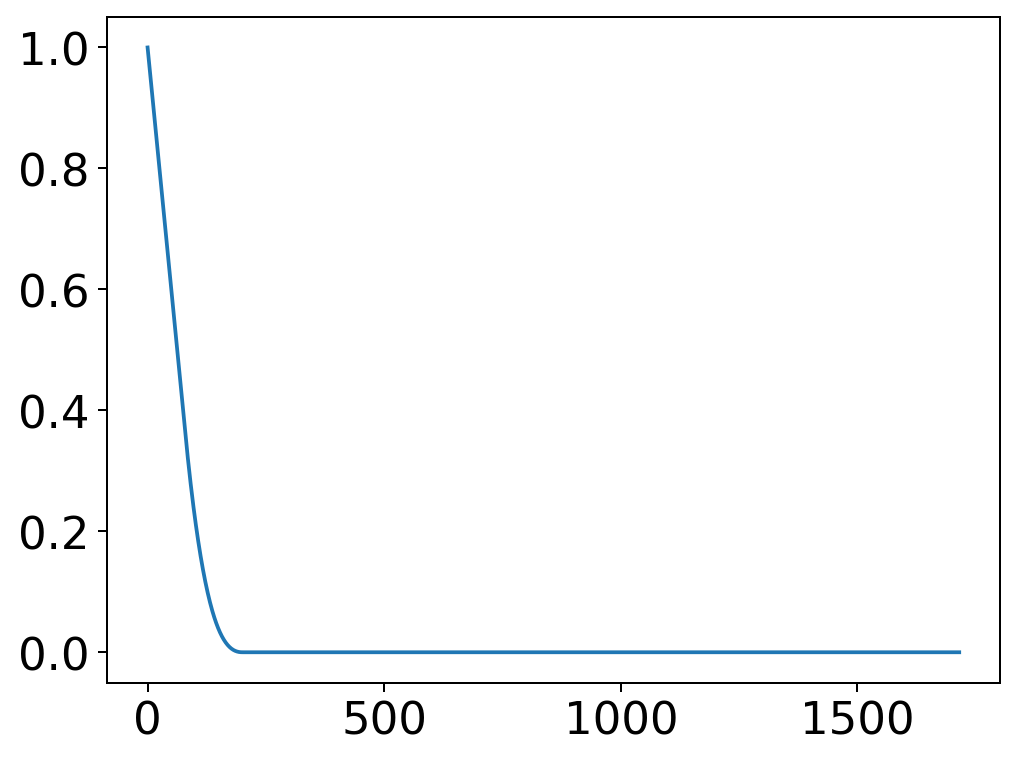

In [12]:
# make an "ideal encoding"
# linear at the start, then gradually flattens
# with value ~0 and slope ~0 by position 200

x = np.arange(full_Npos)
flat_x = 200
linear_until = 80  # increase for a longer linear-looking start

# 1) Linear segment
m = -0.008  # steeper initial slope (more negative = steeper drop)
cos_grid_ideal = np.empty(full_Npos, dtype=float)
cos_grid_ideal[: linear_until + 1] = 1 + m * x[: linear_until + 1]

# 2) Smooth cubic Hermite from x=linear_until to x=200
#    Match value+slope at linear_until, enforce value=0 and slope=0 at 200
x0, x1 = linear_until, flat_x
y0, y1 = 1 + m * x0, 0.0
s0, s1 = m, 0.0

mask = (x > x0) & (x <= x1)
t = (x[mask] - x0) / (x1 - x0)
h00 = 2 * t**3 - 3 * t**2 + 1
h10 = t**3 - 2 * t**2 + t
h01 = -2 * t**3 + 3 * t**2
h11 = t**3 - t**2
cos_grid_ideal[mask] = (
    h00 * y0
    + h10 * (x1 - x0) * s0
    + h01 * y1
    + h11 * (x1 - x0) * s1
)

# 3) Flat after 200
cos_grid_ideal[x > flat_x] = 0.0

# plot cos_grid_ideal
plt.plot(cos_grid_ideal)
plt.show()

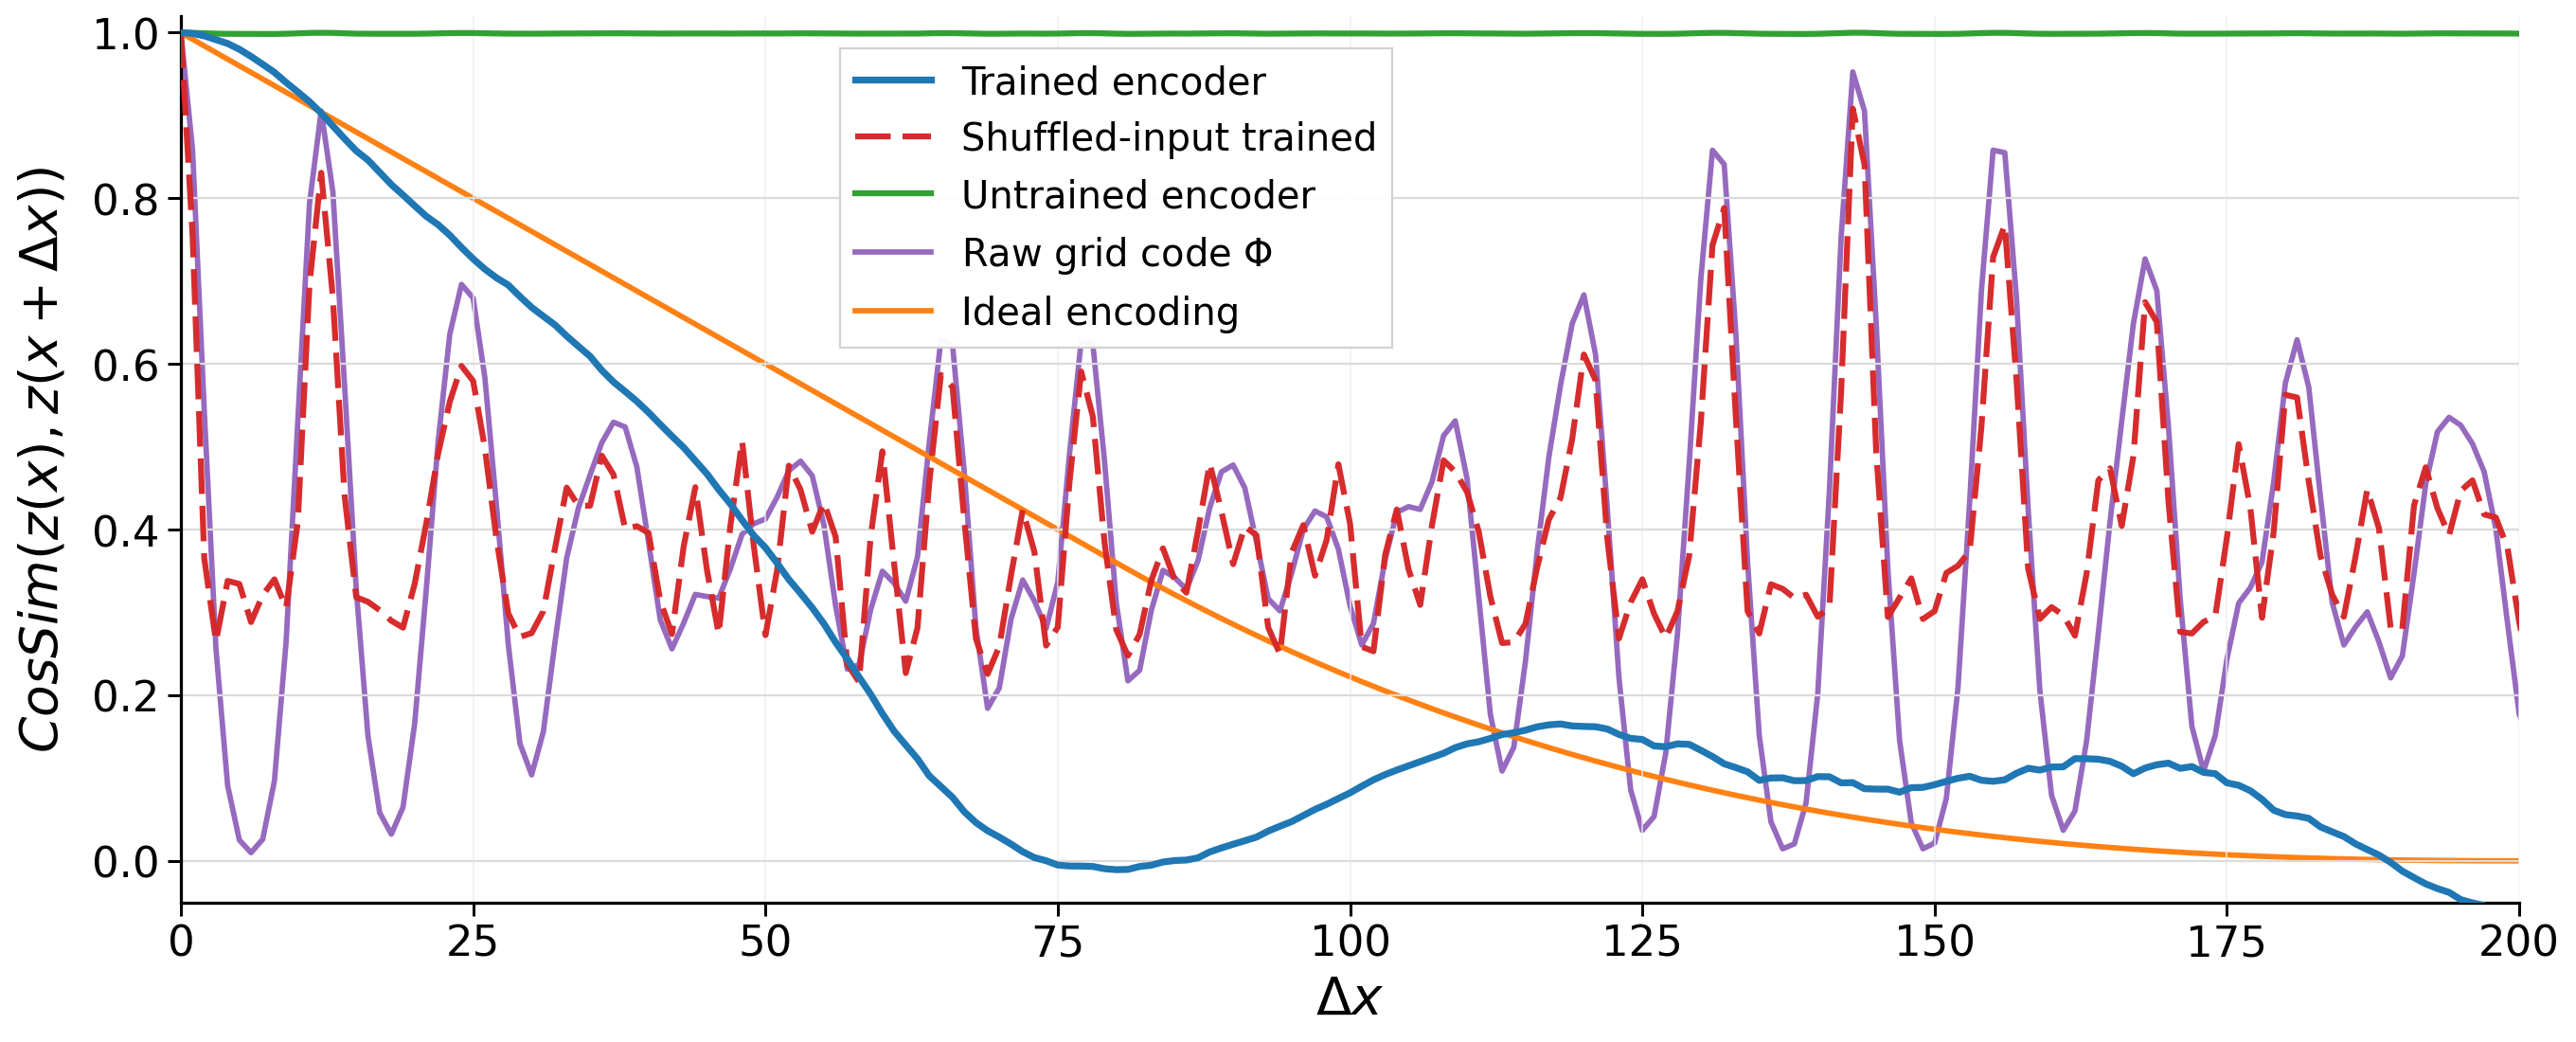

In [36]:
# Publication-style visual defaults for this figure.
plt.rcParams.update(
    {
        "font.size": 17,
        "axes.labelsize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 16,
        "figure.dpi": 180,
        "savefig.dpi": 450,
    }
)

fig, ax = plt.subplots(figsize=(15.0, 6), constrained_layout=True)

# More varied, still colorblind-friendly palette.
color_tr = "#1f77b4"     # trained (blue)
color_shuf = "#d62728"   # shuffled-input trained (red)
color_ut = "#2ca02c"     # untrained (green)
color_grid = "#9467bd"   # raw grid code (purple)
color_ideal = "#ff7f0e"  # ideal encoding (orange)

ax.plot(xs, cos_tr, label="Trained encoder", lw=2.9, color=color_tr, zorder=4)
ax.plot(
    xs,
    cos_shuf,
    label="Shuffled-input trained",
    lw=2.5,
    alpha=0.98,
    ls=(0, (6, 2)),
    color=color_shuf,
    zorder=3,
)
ax.plot(xs, cos_ut, label="Untrained encoder", lw=2.5, alpha=0.98, color=color_ut, zorder=2)
ax.plot(xs, cos_grid, label="Raw grid code $\\Phi$", lw=2.3, alpha=0.98, color=color_grid, zorder=1)
ax.plot(xs, cos_grid_ideal, label="Ideal encoding", lw=2.3, alpha=0.98, color=color_ideal, zorder=1)

#"$\frac{z(x)^{\top}z(x+\Delta x)}{\|z(x)\|_2\,\|z(x+\Delta x)\|_2}$",
ax.set_xlabel(r"$\Delta x$")
ax.set_ylabel(r"$Cos Sim(z(x), z(x+\Delta x))$", labelpad=10)
ax.set_xlim(0, xlim)
ax.set_ylim(-0.05, 1.02)

# Light, publication-like frame and grid.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.3)
ax.spines["bottom"].set_linewidth(1.3)
ax.tick_params(length=5.5, width=1.2)
ax.grid(axis="y", color="0.86", lw=0.9)
ax.grid(axis="x", color="0.93", lw=0.7, alpha=0.8)

leg = ax.legend(
    loc="center",
    bbox_to_anchor=(80, 0.8),
    bbox_transform=ax.transData,
    frameon=True,
    fancybox=False,
    framealpha=0.96,
)
leg.get_frame().set_edgecolor("0.82")
leg.get_frame().set_linewidth(0.9)

# plt.savefig(f'/home/jackking/cls/hopfield_nav/final_figures/ideal_similarity_slice_{xlim}.pdf')
plt.show()

## 4 · Unique-radius polar plot

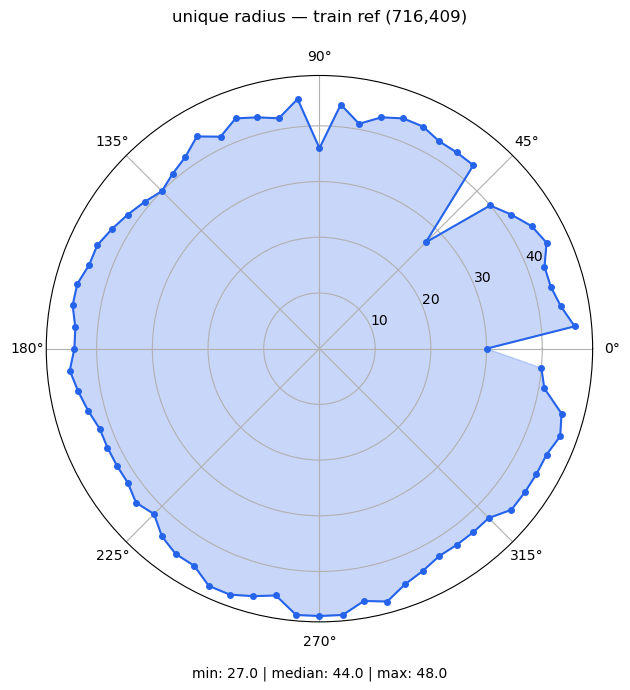

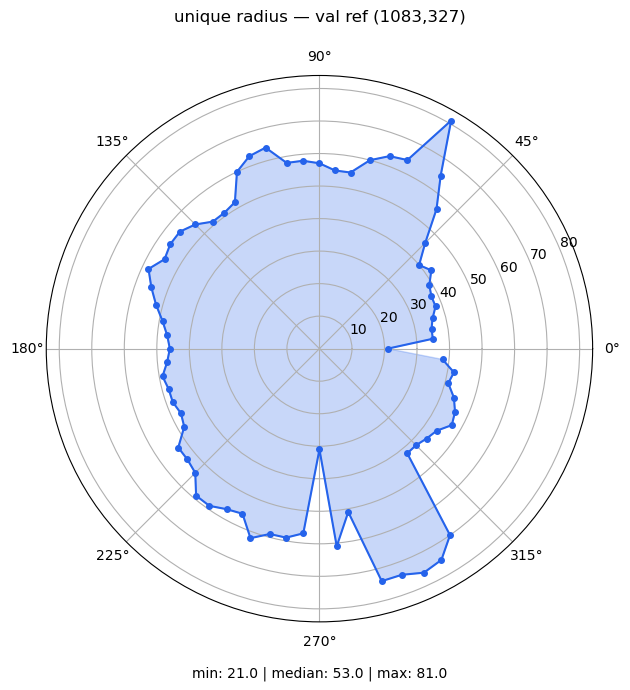

In [24]:
for kind, (ry, rx) in [('train', ref_train), ('val', ref_val)]:
    cos_map = viz.similarity_map(Z, rx, ry)
    thetas, widths = viz.unique_radius_per_theta(cos_map, rx, ry, n_rays=72)
    viz.plot_unique_radius_polar(thetas, widths,
                                  title=f'unique radius — {kind} ref ({ry},{rx})')
    plt.show()

## 5 · Trajectory visualizations

Place a few validation environments outside training patches, seed a
Hopfield with their goal embeddings, and roll out continuous trajectories.

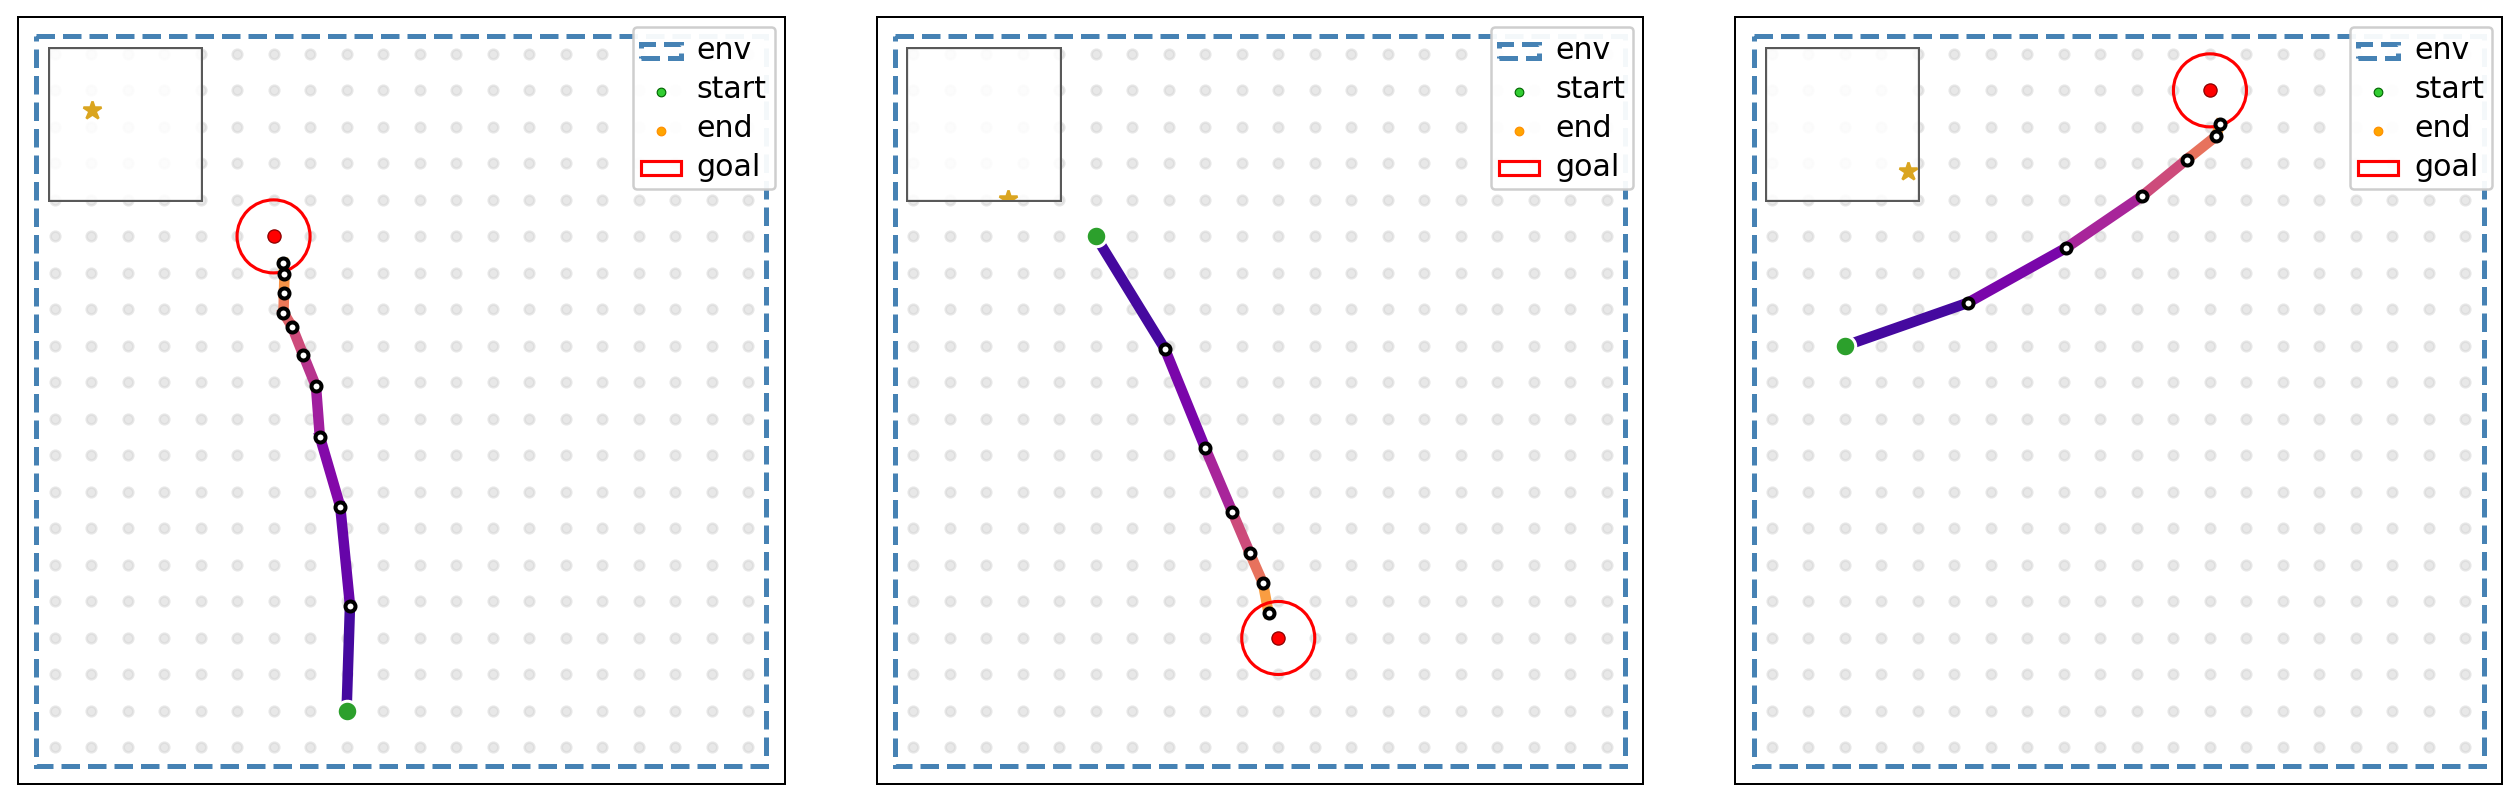

In [35]:
# # Fresh envs every run. Pass rng=np.random.RandomState(seed) to lock.
ENV_SIZE_TRAJ = 20
placements = trajectory.place_random_envs(
    full_Npos=full_Npos, n_envs=3, env_size=ENV_SIZE_TRAJ,
    avoid=list(zip(y0s, x0s, sizes)),
)
envs = trajectory.build_eval_envs(placements, env_size=ENV_SIZE_TRAJ)
hop = trajectory.build_hopfield(Z, envs, gain)

# Same rollouts for full-grid overview + per-env zoom panels.
records = []
for env in envs:
    while True:
        sy = int(np.random.randint(env.y0, env.y0 + env.size))
        sx = int(np.random.randint(env.x0, env.x0 + env.size))
        if (sy, sx) != (env.goal_gx, env.goal_gy):
            break
    traj, angles, mags = trajectory.simulate_trajectory(
        Z, hop, env, start_gx=sy, start_gy=sx, gain=gain,
        max_steps=60, scale=700.0, normalize=False, platform_radius=1.0,
    )
    ended_at_goal = np.linalg.norm(traj[-1] - [env.goal_gx, env.goal_gy]) < 1.0
    records.append((env, traj, angles, mags, ended_at_goal))

# trajectory.plot_all_envs_global(
#     full_Npos,
#     [(e, t) for e, t, _, _, _ in records],
#     method_label="Continuous Method",
# )
# plt.show()

from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, len(envs), figsize=(5 * len(envs), 5))
if len(envs) == 1:
    axes = [axes]
for (env, traj, angles, mags, ended_at_goal), ax in zip(records, axes):
    trajectory.plot_trajectory(env, traj, angles=angles, ax=ax, title="")

    # Thicken native trajectory segments while preserving the gradient colors.
    for ln in ax.lines:
        if ln.get_label() != "start":
            ln.set_linewidth(4.2)
            ln.set_alpha(0.98)

    # Dot marker at every trajectory sample.
    traj_xy = np.asarray(traj)
    if traj_xy.ndim == 2 and traj_xy.shape[1] >= 2 and traj_xy.shape[0] > 0:
        traj_color = ax.lines[-1].get_color() if len(ax.lines) else "C0"
        ax.plot(
            traj_xy[:, 1],
            traj_xy[:, 0],
            linestyle="None",
            marker="o",
            markersize=4.0,
            markerfacecolor="white",
            markeredgewidth=1.6,
            markeredgecolor="black",
            alpha=1.0,
            zorder=8,
        )

        # Explicit start marker (first trajectory point), drawn on top.
        ax.plot(
            traj_xy[0, 1],
            traj_xy[0, 0],
            linestyle="None",
            marker="o",
            markersize=8.2,
            markerfacecolor="#2ca02c",
            markeredgecolor="white",
            markeredgewidth=1.2,
            zorder=10,
            label="start",
        )

    # Remove ticks / title for cleaner publication panels.
    ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])

    # Larger legend text.
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontsize(12)
        leg.get_frame().set_alpha(0.95)

    # Mini-map inset: env location in the full global grid.
    inset = ax.inset_axes([0.04, 0.76, 0.20, 0.20])
    inset.set_xlim(-0.5, full_Npos - 0.5)
    inset.set_ylim(full_Npos - 0.5, -0.5)
    inset.set_aspect("equal")
    inset.add_patch(
        Rectangle((0, 0), full_Npos, full_Npos, fill=False, edgecolor="0.3", linewidth=0.9)
    )
    inset.add_patch(
        Rectangle((env.x0, env.y0), env.size, env.size, fill=False, edgecolor="crimson", linewidth=1.4)
    )
    inset.plot(env.goal_gy, env.goal_gx, marker="*", color="goldenrod", markersize=7.5)
    inset.set_xticks([])
    inset.set_yticks([])
    inset.set_facecolor((1, 1, 1, 0.88))
    for spine in inset.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color("0.35")

fig.subplots_adjust(left=0.05, right=0.97, top=0.96, bottom=0.06, wspace=0.12)
plt.savefig(f'/home/jackking/cls/hopfield_nav/final_figures/1nonnormalized_trajectory_visualizations_{ENV_SIZE_TRAJ}.pdf')
plt.show()